In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

### 🎯 Step 1: Load Data

In [16]:
df = pd.read_csv("loan_data_big.csv")
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Credit_History,Property_Area,Loan_Status
0,Male,Yes,3+,Graduate,Yes,8602.0,85.0,0,Semiurban,0
1,Female,No,3+,Not Graduate,No,8812.0,272.0,1,Urban,0
2,Male,Yes,2,Not Graduate,Yes,6820.0,55.0,1,Semiurban,1
3,Male,Yes,0,Not Graduate,Yes,7632.0,371.0,0,Urban,0
4,Male,No,3+,Graduate,No,9391.0,269.0,1,Semiurban,0
...,...,...,...,...,...,...,...,...,...,...
195,Female,No,3+,Graduate,Yes,5235.0,368.0,1,Urban,0
196,Female,No,0,Graduate,Yes,9934.0,104.0,1,Rural,1
197,Female,No,2,Graduate,No,4090.0,198.0,1,Semiurban,1
198,Male,No,3+,Graduate,No,2563.0,358.0,1,Urban,0


### 🧠 Step 2: Preprocessing
1. Handling missing values and ecoding

In [3]:
df.isnull().sum()

Gender             6
Married            1
Dependents         1
Education          7
Self_Employed      0
ApplicantIncome    2
LoanAmount         2
Credit_History     0
Property_Area      5
Loan_Status        0
dtype: int64

In [4]:
df['Gender'].ffill(inplace = True)
df['Married'].bfill(inplace = True)
df['Dependents'].bfill(inplace = True)
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)
df['Education'].fillna(df['Education'].mode()[0], inplace = True)
df['ApplicantIncome'].fillna(df['ApplicantIncome'].mean(), inplace = True)
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace = True)
df['Property_Area'].fillna(df['Property_Area'].mode()[0], inplace = True)
df.isnull().sum()

Gender             0
Married            0
Dependents         0
Education          0
Self_Employed      0
ApplicantIncome    0
LoanAmount         0
Credit_History     0
Property_Area      0
Loan_Status        0
dtype: int64

In [5]:
df['Gender'] = df['Gender'].map({'Male' : 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes':1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes' : 1, 'No': 0})

# One-hot encoding
df = pd.get_dummies(df, columns = ['Property_Area'], drop_first = True)

### ✂️ Step 3: Split Data

In [6]:
x = df.drop('Loan_Status', axis = 1)
y = df['Loan_Status']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

### 🤖 Step 4: Train Models

In [8]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [9]:
lr = LogisticRegression(
    max_iter = 1000
)
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)

In [10]:
xgb = XGBClassifier(
    n_estimators = 100,
    max_depth = 3,
    learning_rate = 0.1,
    eval_metric = 'logloss',
    use_label_encoder = False
)
xgb.fit(x_train,y_train)
xgb_pred = xgb.predict(x_test)

In [11]:
rf = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 3,
    min_samples_split = 5,
)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

### Evaluating the performace of each model

In [12]:
# Now we will check the accuracy
print("Accuracy for LR:", accuracy_score(y_test, lr_pred))
print("Accuracy for XGB:", accuracy_score(y_test, xgb_pred))
print("Accuracy for RF:", accuracy_score(y_test, rf_pred))

Accuracy for LR: 0.925
Accuracy for XGB: 0.975
Accuracy for RF: 0.95


### 🔍 Step 5: Feature Importance

In [13]:
importance = rf.feature_importances_
fea_impt = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
}).sort_values(by = 'Importance', ascending = False)
print(fea_impt)

                   Feature  Importance
6               LoanAmount    0.523078
7           Credit_History    0.238445
5          ApplicantIncome    0.173315
1                  Married    0.012102
3                Education    0.011831
2               Dependents    0.011299
8  Property_Area_Semiurban    0.008940
0                   Gender    0.008750
9      Property_Area_Urban    0.007950
4            Self_Employed    0.004290


In [14]:
import matplotlib.pyplot as plt

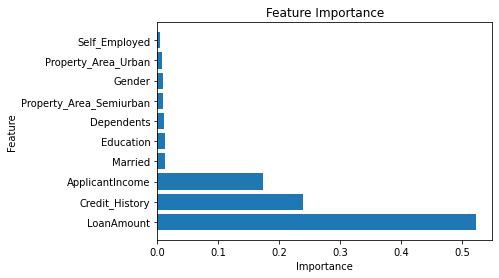

In [15]:
plt.barh(fea_impt['Feature'], fea_impt['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.show()